In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Website URL
url = "https://books.toscrape.com/"

# Send a request to the website
response = requests.get(url)

# Check the response status
print(response.status_code)

# Parse the HTML content
soup = BeautifulSoup(response.text, "html.parser")

# Display the page title
print(soup.title.text)

200

    All products | Books to Scrape - Sandbox



In [2]:
# Find all book containers on the page
books = soup.find_all("article", class_="product_pod")

# Create an empty list to store the scraped data
data = []

# Extract information from each book
for book in books:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text
    rating = book.find("p", class_="star-rating")["class"][1]

    data.append({
        "Book Name": title,
        "Price": price,
        "Rating": rating
    })

# Display the first 5 records
print(data[:5])

[{'Book Name': 'A Light in the Attic', 'Price': 'Â£51.77', 'Rating': 'Three'}, {'Book Name': 'Tipping the Velvet', 'Price': 'Â£53.74', 'Rating': 'One'}, {'Book Name': 'Soumission', 'Price': 'Â£50.10', 'Rating': 'One'}, {'Book Name': 'Sharp Objects', 'Price': 'Â£47.82', 'Rating': 'Four'}, {'Book Name': 'Sapiens: A Brief History of Humankind', 'Price': 'Â£54.23', 'Rating': 'Five'}]


In [3]:
# Convert the scraped data into a DataFrame
df = pd.DataFrame(data)

# Display the first 10 rows
df.head(10)

,Book Name,Price,Rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five
5,The Requiem Red,Â£22.65,One
6,The Dirty Little Secrets of Getting Your Dream...,Â£33.34,Four
7,The Coming Woman: A Novel Based on the Life of...,Â£17.93,Three
8,The Boys in the Boat: Nine Americans and Their...,Â£22.60,Four
9,The Black Maria,Â£52.15,One


In [5]:
# Remove the currency symbol and convert Price to numeric
df["Price"] = df["Price"].str.replace("Â£", "", regex=False).astype(float)

# Convert ratings from words to numbers
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)

# Display the cleaned data
df.head(10)

,Book Name,Price,Rating
0,A Light in the Attic,51.77,3
1,Tipping the Velvet,53.74,1
2,Soumission,50.10,1
3,Sharp Objects,47.82,4
4,Sapiens: A Brief History of Humankind,54.23,5
5,The Requiem Red,22.65,1
6,The Dirty Little Secrets of Getting Your Dream...,33.34,4
7,The Coming Woman: A Novel Based on the Life of...,17.93,3
8,The Boys in the Boat: Nine Americans and Their...,22.60,4
9,The Black Maria,52.15,1


In [6]:
# Check the number of rows and columns
print("Dataset Shape:", df.shape)

# Check the data types
print("\nData Types:")
print(df.dtypes)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (20, 3)

Data Types:
Book Name     object
Price        float64
Rating         int64
dtype: object

Missing Values:
Book Name    0
Price        0
Rating       0
dtype: int64


In [7]:
# Save the scraped data to a CSV file
df.to_csv("CodeAlpha_Task1_Web_Scraping.csv", index=False)

print("CSV file saved successfully!")

CSV file saved successfully!


In [8]:
from google.colab import files

files.download("CodeAlpha_Task1_Web_Scraping.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# Find the highest-priced book
highest_price = df.loc[df["Price"].idxmax()]

print("Highest Priced Book:")
print(highest_price)

# Find the lowest-priced book
lowest_price = df.loc[df["Price"].idxmin()]

print("\nLowest Priced Book:")
print(lowest_price)

# Calculate the average price
average_price = df["Price"].mean()

print("\nAverage Book Price:", round(average_price, 2))

Highest Priced Book:
Book Name    Our Band Could Be Your Life: Scenes from the A...
Price                                                    57.25
Rating                                                       3
Name: 15, dtype: object

Lowest Priced Book:
Book Name    Starving Hearts (Triangular Trade Trilogy, #1)
Price                                                 13.99
Rating                                                    2
Name: 10, dtype: object

Average Book Price: 38.05


In [10]:
# Count books for each rating
rating_counts = df["Rating"].value_counts().sort_index()

print("Number of Books by Rating:")
print(rating_counts)

Number of Books by Rating:
Rating
1    6
2    3
3    3
4    4
5    4
Name: count, dtype: int64


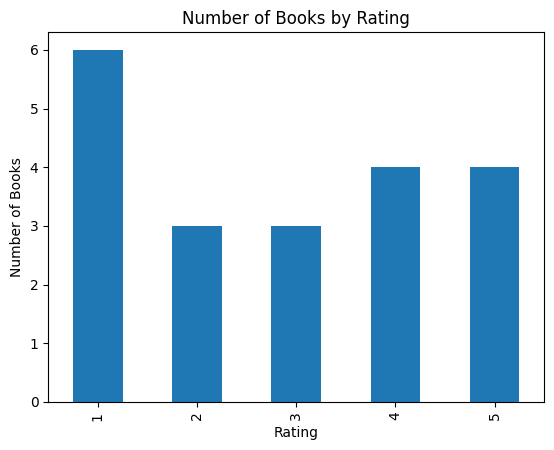

In [11]:
import matplotlib.pyplot as plt

rating_counts.plot(kind="bar")

plt.title("Number of Books by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.show()

/tmp/ipykernel_1681/4280972508.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


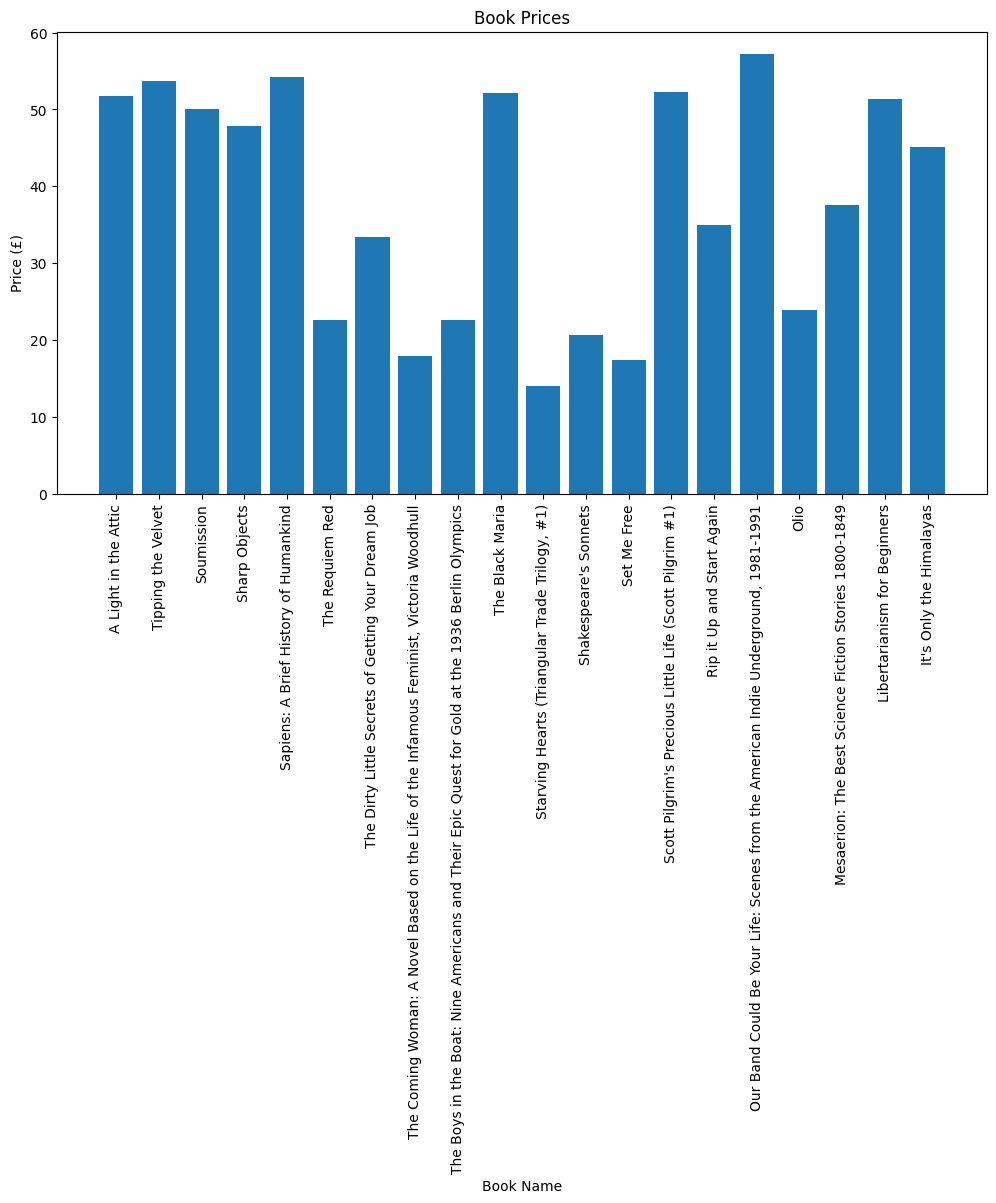

In [12]:
import matplotlib.pyplot as plt

# Create a price chart for the books
plt.figure(figsize=(12, 6))

plt.bar(df["Book Name"], df["Price"])

plt.title("Book Prices")
plt.xlabel("Book Name")
plt.ylabel("Price (£)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [13]:
# Find the top 5 most expensive books
top_5_expensive = df.sort_values("Price", ascending=False).head(5)

print(top_5_expensive[["Book Name", "Price"]])

                                            Book Name  Price
15  Our Band Could Be Your Life: Scenes from the A...  57.25
4               Sapiens: A Brief History of Humankind  54.23
1                                  Tipping the Velvet  53.74
13  Scott Pilgrim's Precious Little Life (Scott Pi...  52.29
9                                     The Black Maria  52.15


/tmp/ipykernel_1681/933691180.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


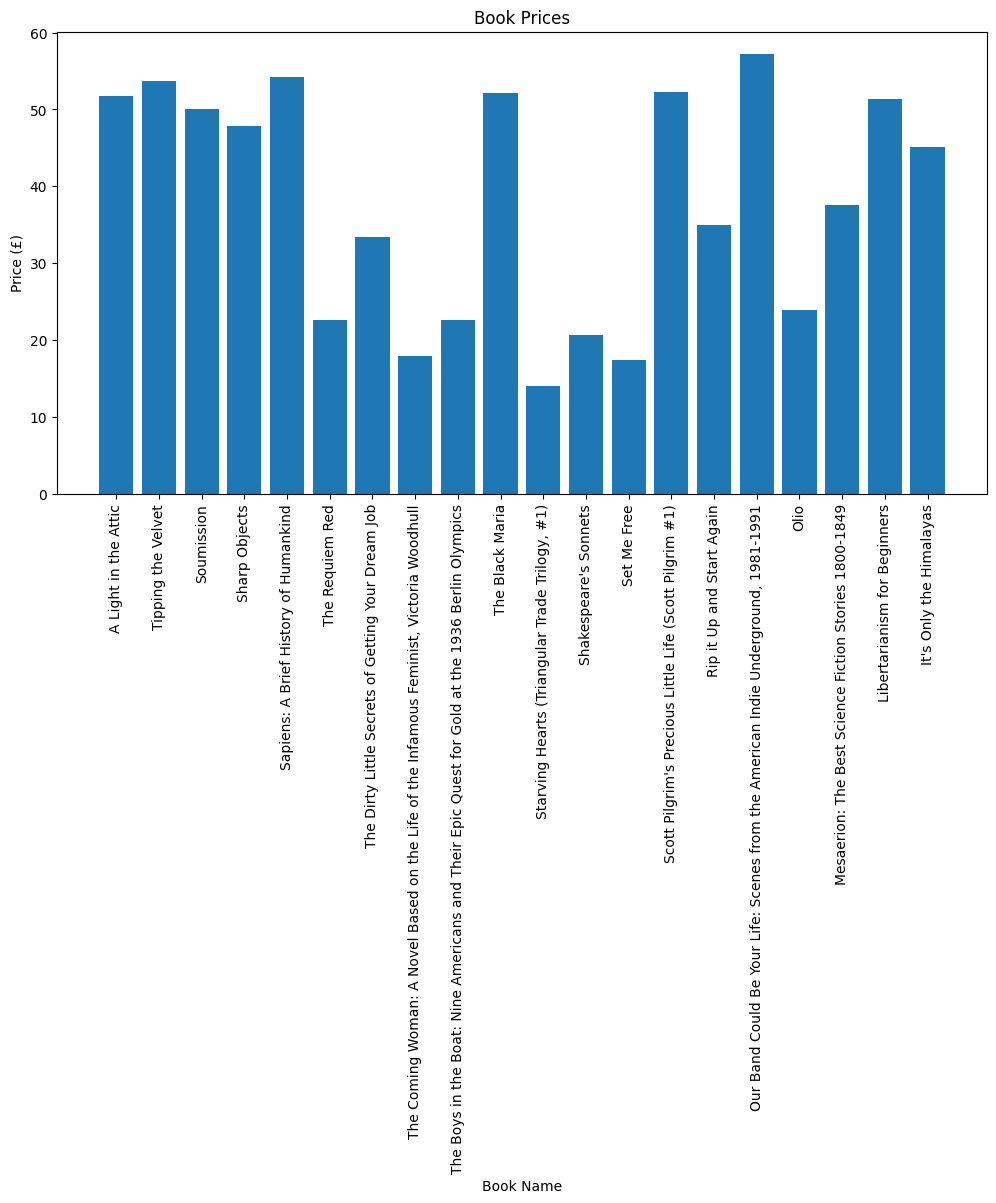

In [14]:
plt.figure(figsize=(12, 6))

plt.bar(df["Book Name"], df["Price"])

plt.title("Book Prices")
plt.xlabel("Book Name")
plt.ylabel("Price (£)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig("Book_Prices.png", dpi=300)
plt.show()

In [15]:
# Find the top 5 most expensive books
top_5_expensive = df.sort_values("Price", ascending=False).head(5)

print("Top 5 Most Expensive Books:")
print(top_5_expensive[["Book Name", "Price"]])

Top 5 Most Expensive Books:
                                            Book Name  Price
15  Our Band Could Be Your Life: Scenes from the A...  57.25
4               Sapiens: A Brief History of Humankind  54.23
1                                  Tipping the Velvet  53.74
13  Scott Pilgrim's Precious Little Life (Scott Pi...  52.29
9                                     The Black Maria  52.15


In [17]:
# Count books for each rating
rating_counts = df["Rating"].value_counts().sort_index()

print("Books by Rating:")
print(rating_counts)

Books by Rating:
Rating
1    6
2    3
3    3
4    4
5    4
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(rating_counts.index, rating_counts.values)

plt.title("Number of Books by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()

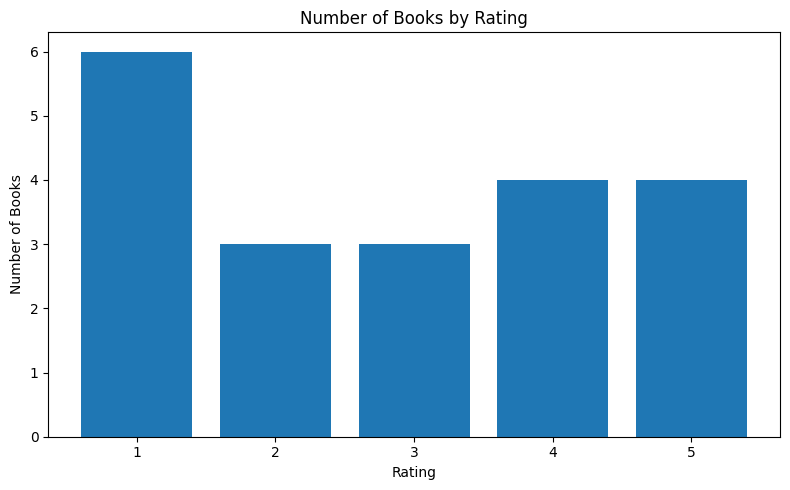

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(rating_counts.index, rating_counts.values)

plt.title("Number of Books by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.savefig("Books_by_Rating.png", dpi=300)
plt.show()

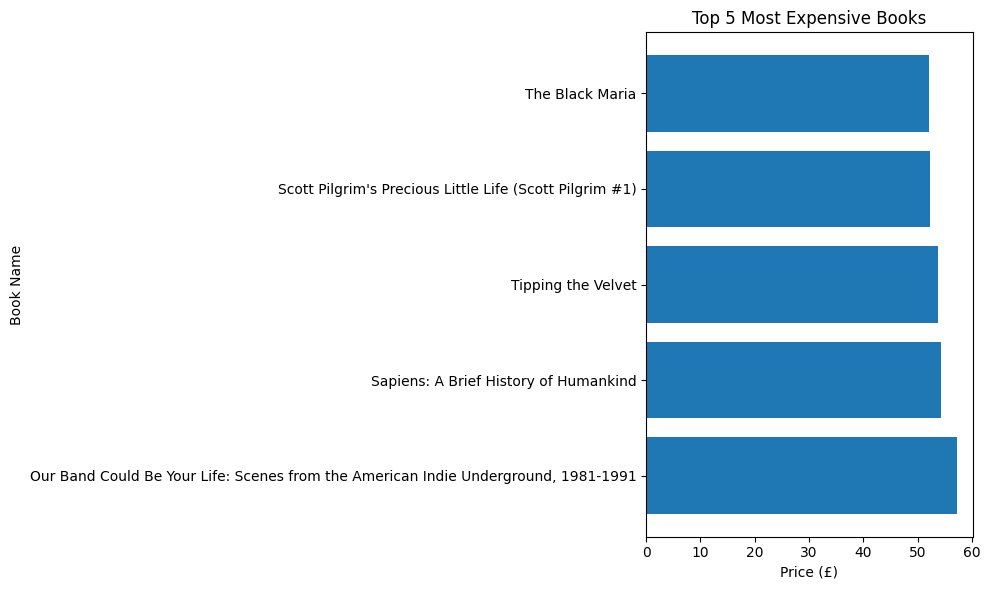

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(top_5_expensive["Book Name"], top_5_expensive["Price"])

plt.title("Top 5 Most Expensive Books")
plt.xlabel("Price (£)")
plt.ylabel("Book Name")

plt.tight_layout()
plt.show()

In [19]:
# Find the most expensive book
most_expensive = df.loc[df["Price"].idxmax()]

# Find the cheapest book
cheapest = df.loc[df["Price"].idxmin()]

print("Most Expensive Book:")
print(most_expensive["Book Name"], "-", most_expensive["Price"])

print("\nCheapest Book:")
print(cheapest["Book Name"], "-", cheapest["Price"])

Most Expensive Book:
Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991 - 57.25

Cheapest Book:
Starving Hearts (Triangular Trade Trilogy, #1) - 13.99
